In [37]:
# IMPORT ALL THINGS POSSIABLY NEEDED 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

from sklearn.tree import DecisionTreeClassifier

In [4]:
# Run of data
df = pd.read_csv("data/blood_cell_anomaly_detection.csv")
print("Head!")
print(df.head())
print()

print("Describe!")
print(df.describe())
print()

# Target Column 
print("=====================")
print("I pick Anomaly Label!")
print("=====================")

Head!
       cell_id                  cell_type  anomaly_label disease_category  \
0  CELL_005371  Hypersegmented_Neutrophil              1        Infection   
1  CELL_005300  Hypersegmented_Neutrophil              1        Infection   
2  CELL_000200                 Neutrophil              0       Normal_WBC   
3  CELL_003269                 Normal_RBC              0       Normal_RBC   
4  CELL_003505                 Normal_RBC              0       Normal_RBC   

   cell_diameter_um  nucleus_area_pct  chromatin_density  cytoplasm_ratio  \
0             15.18              58.8              0.542            0.301   
1             16.47              73.6              0.583            0.365   
2             13.41              55.5              0.448            0.376   
3              7.36               0.0              0.000            1.000   
4              7.53               0.0              0.000            1.000   

   circularity  eccentricity  ...  mcv_fl  mchc_g_dl  dataset_source

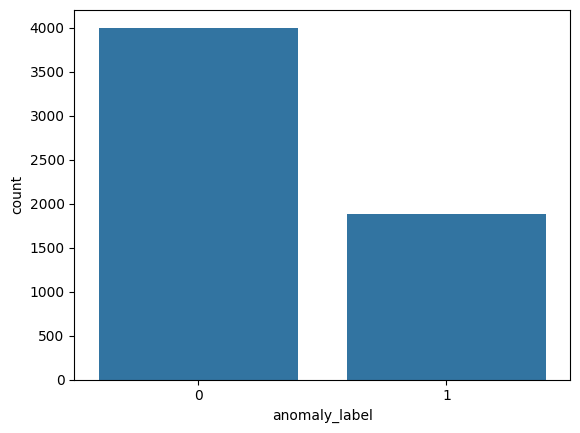

cell_id                                    0
cell_type                                  0
anomaly_label                              0
disease_category                           0
cell_diameter_um                           0
nucleus_area_pct                           0
chromatin_density                          0
cytoplasm_ratio                            0
circularity                                0
eccentricity                               0
granularity_score                          0
lobularity_score                           0
membrane_smoothness                        0
cell_area_px                               0
perimeter_px                               0
mean_r                                     0
mean_g                                     0
mean_b                                     0
stain_intensity                            0
patient_age_group                          0
patient_sex                                0
wbc_count_per_ul                           0
rbc_count_

In [5]:
# Distribution
df["anomaly_label"].value_counts()
sns.countplot(x = "anomaly_label", data = df)
plt.show()

# Missing Values
df.isnull().sum()

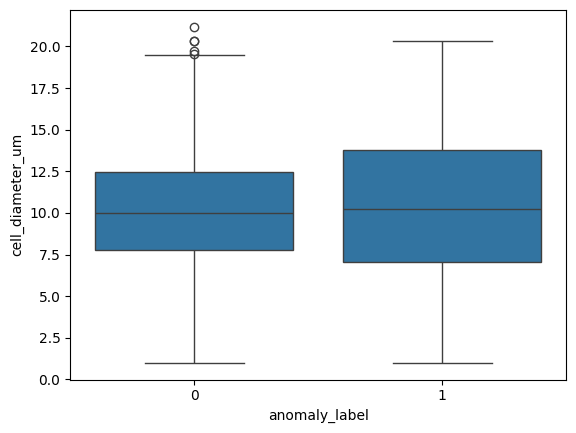

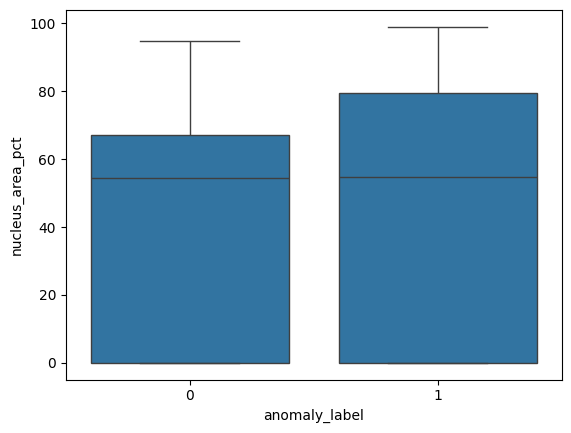

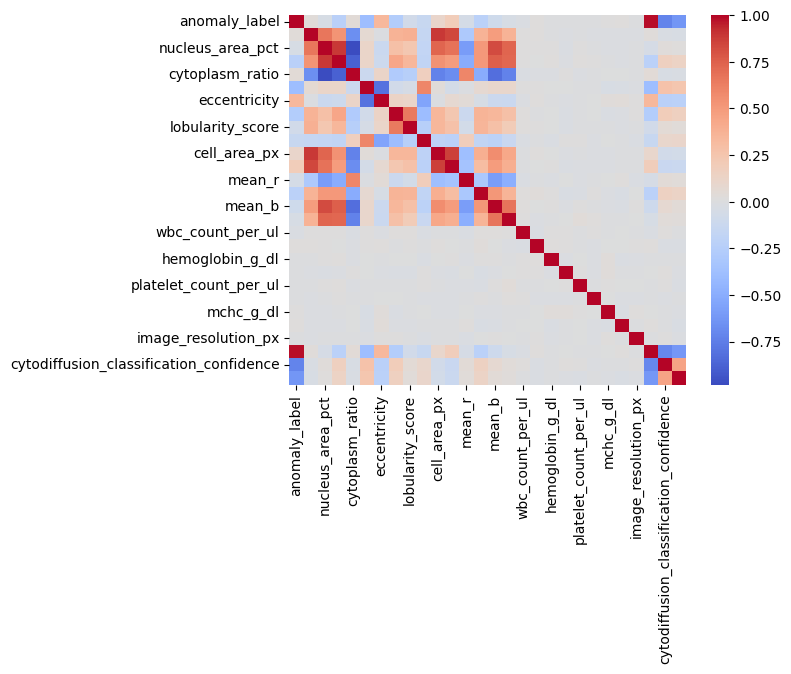

In [6]:
# Easy Visuals and Correlation
sns.boxplot(x = "anomaly_label", y = "cell_diameter_um", data = df)
plt.show()

sns.boxplot(x = "anomaly_label", y = "nucleus_area_pct", data = df)
plt.show()

sns.heatmap(df.corr(numeric_only = True), cmap = "coolwarm")
plt.show()

The dataset shows a difference in the number of normal and abnormal cells, with normal cells appearing more frequently, which may affect how the model learns patterns. There are no missing values in the dataset, meaning all features are complete and can be used without additional cleaning. The visualizations show some separation between normal and abnormal cells in features like cell diameter and nucleus area, suggesting that these measurements may help the model distinguish between the two groups.

In [7]:
# Step 3

#Size Ratio
df["size_ratio"] = df["cell_diameter_um"] / (df["nucleus_area_pct"] + 1)

#Density
df["density"] = df["hemoglobin_g_dl"] / df["cell_diameter_um"]

# Shape Index
df["shape_index"] = df["circularity"] * df["cell_diameter_um"]

#Check
print(df.head())

       cell_id                  cell_type  anomaly_label disease_category  \
0  CELL_005371  Hypersegmented_Neutrophil              1        Infection   
1  CELL_005300  Hypersegmented_Neutrophil              1        Infection   
2  CELL_000200                 Neutrophil              0       Normal_WBC   
3  CELL_003269                 Normal_RBC              0       Normal_RBC   
4  CELL_003505                 Normal_RBC              0       Normal_RBC   

   cell_diameter_um  nucleus_area_pct  chromatin_density  cytoplasm_ratio  \
0             15.18              58.8              0.542            0.301   
1             16.47              73.6              0.583            0.365   
2             13.41              55.5              0.448            0.376   
3              7.36               0.0              0.000            1.000   
4              7.53               0.0              0.000            1.000   

   circularity  eccentricity  ...  staining_protocol  microscope_model  \


Feature 1

Feature name and calculation: The size ratio feature was created by dividing cell diameter by nucleus area. This combines two measurements into one value that reflects how large the cell is compared to the size of its nucleus.

Why it should help: This feature helps capture the relationship between overall cell size and nucleus size, which may not be as clear when looking at each feature separately. Abnormal cells often show changes in this balance.

Domain justification: In biology, changes in the size of the nucleus compared to the rest of the cell are commonly used as indicators of abnormal cell behavior, especially in disease conditions.

Feature 2

Feature name and calculation: The density feature was created by dividing hemoglobin by cell diameter. This gives a measure of how concentrated hemoglobin is relative to the size of the cell.

Why it should help: This feature may highlight differences in how much hemoglobin is present in cells of different sizes, which may not be obvious when looking at each variable on its own.

Domain justification: Hemoglobin levels are important for understanding blood cell function, and abnormal levels can be linked to disease, making this a useful feature for identifying abnormal cells.

Feature 3

Feature name and calculation: The shape index feature was created by multiplying circularity by cell diameter. This combines shape and size into a single value.

Why it should help: This feature captures both how round a cell is and how large it is, which may help separate normal cells from abnormal ones more clearly.

Domain justification: Abnormal cells often show irregular shapes and changes in size, so combining these two characteristics can help better represent those changes.

In [8]:
# Dropping all non Numberical Columns
df = df.drop(columns=["cell_id", "dataset_source", "cell_type", "disease_category", "patient_age_group", "patient_sex", "staining_protocol", "microscope_model"])

In [9]:
# Step 4

# Split feature 
X = df.drop("anomaly_label", axis=1)
y = df["anomaly_label"]

# Train 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scale
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The data was split into training and test sets using an 80/20 split, with stratification applied to maintain the balance between normal and abnormal cells. There were no missing values in the dataset, but rows with non numerical values from feature calculations were removed to make sure the data was clean. All numerical features were scaled using StandardScaler so that differences in measurement size did not affect model performance.

In [10]:
# Step 5

rf = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf.fit(X_train, y_train)

# Predicitions
y_pred_rf = rf.predict(X_test)

# Accuracy
accuracy_score(y_test, y_pred_rf)

# Full report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       800
           1       1.00      1.00      1.00       376

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



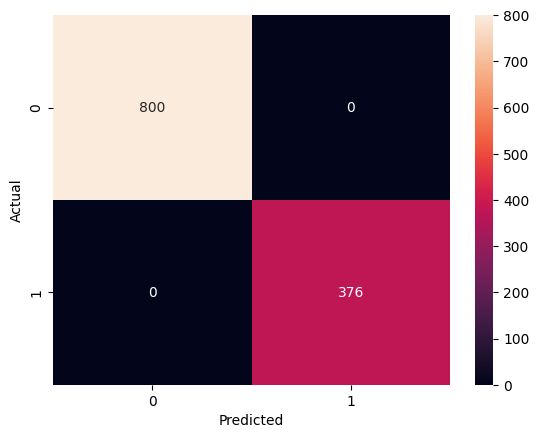

In [11]:
# Heat Map
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot = True, fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

A Random Forest model was used to classify normal and abnormal cells based on the features in the dataset. The model was trained on the training data and test data, where it showed very strong performance with correct predictions for both classes. The results suggest that the features used in this dataset clearly separate normal and abnormal cells, allowing the model to classify them with high accuracy.

In [12]:
# Step 6

# Train Model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Accarte
accuracy_score(y_test, y_pred_dt)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       800
           1       1.00      1.00      1.00       376

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



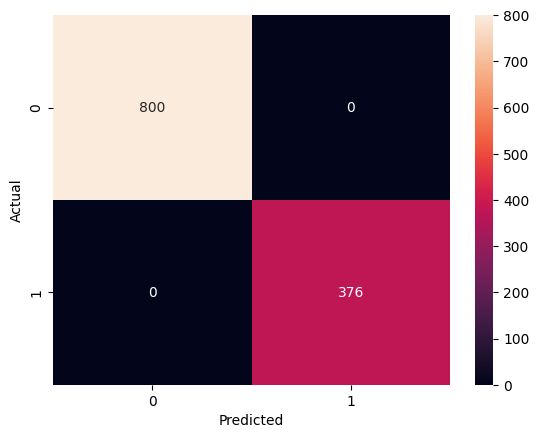

In [13]:
# Heat Confusion Map
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot = True, fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

A Decision Tree model was used as a second approach to classify normal and abnormal cells. The model was trained and tested using the same data split as the Random Forest model. The results showed that the model produced the same performance, correctly classifying all samples and suggested that the patterns in the dataset are clear enough that even a simpler model can achieve high accuracy.

In [14]:
# Step 7

results = pd.DataFrame({"Model": ["Random Forest", "Decision Tree"], "Accuracy": [accuracy_score(y_test, y_pred_rf),accuracy_score(y_test, y_pred_dt)]})

results

,Model,Accuracy
0,Random Forest,1.0
1,Decision Tree,1.0


Both the Random Forest and Decision Tree models performed equally well, with both models correctly classifying all samples in the dataset. This is likely because the features clearly separate normal and abnormal cells, making it easier for both models to learn the patterns. The main trade-off between the two models is that random forest is more complex, while the decision tree is simpler and easier to understand. Based on this, the decision tree model is would be more perferred because it provides the same performance while being easier to understand.

**WEEK 13 PARTS OF THE DRAFT**

In [ ]:
# Addition of the new features

# Convert % to decimal
df['nucleus_area'] = df['nucleus_area_pct'] / 100

# Ratio of nucleus size to cell diameter
df['nucleus_to_diameter_ratio'] = df['nucleus_area'] / df['cell_diameter_um']

# Combined size feature
df['size_interaction'] = df['cell_diameter_um'] * df['nucleus_area']

# To test a hypothesis if smaller=abnormal
df['inverse_diameter'] = 1 / df['cell_diameter_um']

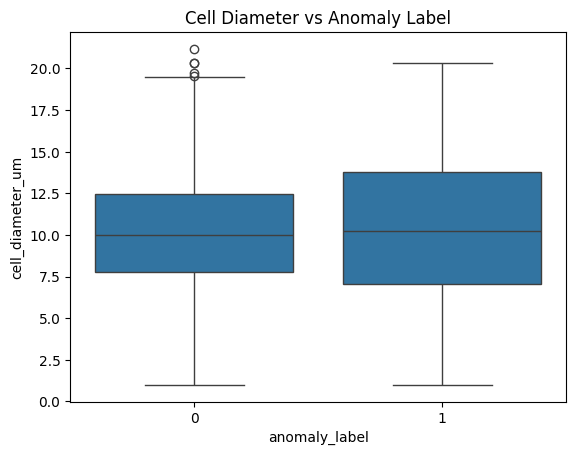

In [19]:
# Visualize Data

sns.boxplot(data=df, x='anomaly_label', y='cell_diameter_um')
plt.title('Cell Diameter vs Anomaly Label')
plt.show()

# Features
features = [
    'cell_diameter_um',
    'nucleus_area',
    'nucleus_to_diameter_ratio',
    'size_interaction',
    'inverse_diameter'
]

X = df[features]
y = df['anomaly_label']

Feature 4

Feature name and calculation: The nucleus to diameter ratio feature was created by dividing the normalized nucleus area by the cell diameter. This combines the internal structure of the cell with its overall size into a single value that reflects how large the nucleus is compared to the full cell.

Why it should help: This feature helps show the balance between nucleus size and cell size, which may not be as clear of an indication when looking at each feature separately. Abnormal cells often show a weird nucleus compared to the rest of the cell, and this makes that pattern easier for the model to detect.

Domain justification: In biology, the relationship between nucleus size and overall cell size is commonly used when identifying abnormal cells. A nucleus that takes up a larger portion of the cell can be a sign of irregular or diseased cell behavior.

Feature 5

Feature name and calculation: The size interaction feature was created by multiplying cell diameter by the normalized nucleus area. This combines both measurements into one value that can show how overall cell size and nucleus size interact with each other.

Why it should help: This feature shows the combined effect of cell size and nucleus size, rather than treating them as separate values. Certain combinations of these measurements may be more common in abnormal cells, and this feature helps highlight those patterns.

Domain justification: In biological analysis, both the size of a cell and the size of its nucleus are important indicators of cell health. Looking at how these two measurements interact can provide additional looks into abnormal cell structures.

Feature 6

Feature name and calculation: The inverse diameter feature was created by taking the inverse of the cell diameter. This transforms smaller diameter values into larger ones, making it easier to show differences in smaller cells.

Why it should help: This feature helps show patterns where smaller cells may be more likely to be classified as abnormal. By using the values in this way, the model can more easily detect relationships related to small cell size.

Domain justification: In biological contexts, abnormal cells can sometimes appear smaller or have irregular size distributions. Emphasizing smaller cell sizes allows the model to better capture these differences and improve classification performance.

In [25]:
# Decision Tree tuning
dt1 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt2 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt3 = DecisionTreeClassifier(max_depth=10, random_state=42)

dt1.fit(X_train, y_train)
dt2.fit(X_train, y_train)
dt3.fit(X_train, y_train)

print("DT depth=3:", dt1.score(X_test, y_test))
print("DT depth=5:", dt2.score(X_test, y_test))
print("DT depth=10:", dt3.score(X_test, y_test))

DT depth=3: 0.7619047619047619
DT depth=5: 0.8299319727891157
DT depth=10: 0.8171768707482994


In [26]:
# Evaluate
rf1 = RandomForestClassifier(n_estimators=50, random_state=42)
rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf3 = RandomForestClassifier(n_estimators=200, random_state=42)

rf1.fit(X_train, y_train)
rf2.fit(X_train, y_train)
rf3.fit(X_train, y_train)

print("RF 50 trees:", rf1.score(X_test, y_test))
print("RF 100 trees:", rf2.score(X_test, y_test))
print("RF 200 trees:", rf3.score(X_test, y_test))

RF 50 trees: 0.8086734693877551
RF 100 trees: 0.8120748299319728
RF 200 trees: 0.8086734693877551


Different configurations of both models were tested by adjusting the depth of the Decision Tree and the number of trees in the Random Forest. For the Decision Tree, a max depth of 5 produced the best performance, while a lower depth of 3 resulted in lower accuracy and a higher depth of 10 did not provide improvement. This tells us that a moderate depth allows the model to capture patterns without overfitting.

For the Random Forest, increasing the number of trees from 50 to 100 slightly improved performance, but increasing it further to 200 did not lead to additional gains. This indicates that adding more trees beyond a certain point does not significantly improve the model and may add unnecessary complexity.

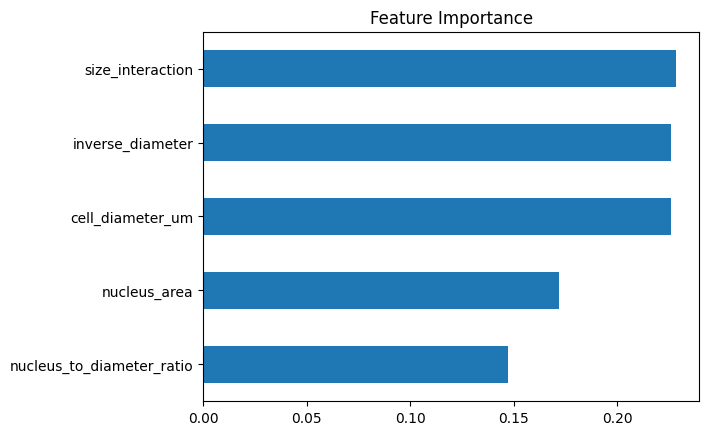

In [27]:
importances = rf2.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values()

feat_imp.plot(kind='barh')
plt.title('Feature Importance')
plt.show()

The feature importance results show a clear difference compared to the initial draft, where both models achieved perfect accuracy but did not show which features mattered. The size interaction feature has the highest importance, followed by inverse diameter and cell diameter. This supports the goal of the project which is to see if the anomonly of the cell can be shown using other features such as cell diameter or nucleus area. This shows that cell size and its relationship with nucleus area are strongly connected to the anomaly label. These results suggest that abnormal cells can be identified based on differences in size, especially when features are combined.

Compared to the first draft, the updated model shows more realistic performance and clearer patterns. The lower accuracy indicates that the model is learning meaningful relationships rather than memorizing the data, confirming that the new features improve the overall analysis.

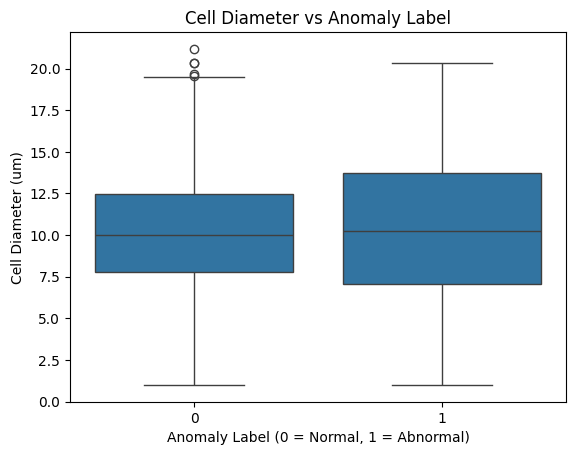

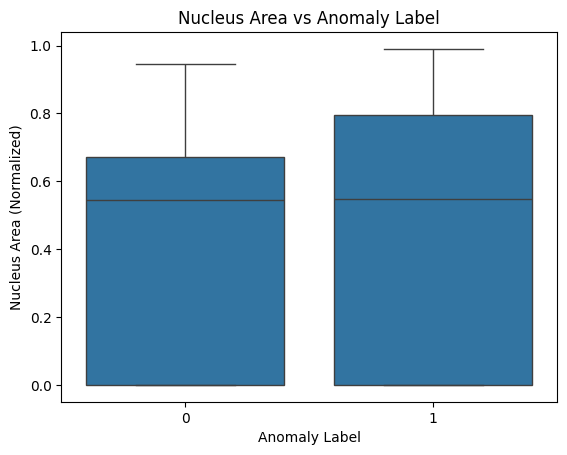

Cell Diameter Mean Difference: -0.269008457446807
Nucleus Area Mean Difference: 0.031999829787234035


In [36]:
# Blox Plot
sns.boxplot(data=df, x='anomaly_label', y='cell_diameter_um')
plt.title('Cell Diameter vs Anomaly Label')
plt.xlabel('Anomaly Label (0 = Normal, 1 = Abnormal)')
plt.ylabel('Cell Diameter (um)')
plt.show()

sns.boxplot(data=df, x='anomaly_label', y='nucleus_area')
plt.title('Nucleus Area vs Anomaly Label')
plt.xlabel('Anomaly Label')
plt.ylabel('Nucleus Area (Normalized)')
plt.show()

# Calculations
normal = df[df['anomaly_label'] == 0]
abnormal = df[df['anomaly_label'] == 1]

# Cell Diameter difference
cd_diff = normal['cell_diameter_um'].mean() - abnormal['cell_diameter_um'].mean()

# Nucleus Area difference
na_diff = normal['nucleus_area'].mean() - abnormal['nucleus_area'].mean()

print("Cell Diameter Mean Difference:", cd_diff)
print("Nucleus Area Mean Difference:", na_diff)

The boxplots show that cell diameter has a clearer difference between normal and abnormal cells, supported by a mean difference of -0.269, indicating abnormal cells tend to be smaller. In comparison, nucleus area shows very little separation, with a mean difference of only 0.032. This suggests that cell diameter is more strongly related to the anomaly label, while nucleus area is more useful when combined with other features.

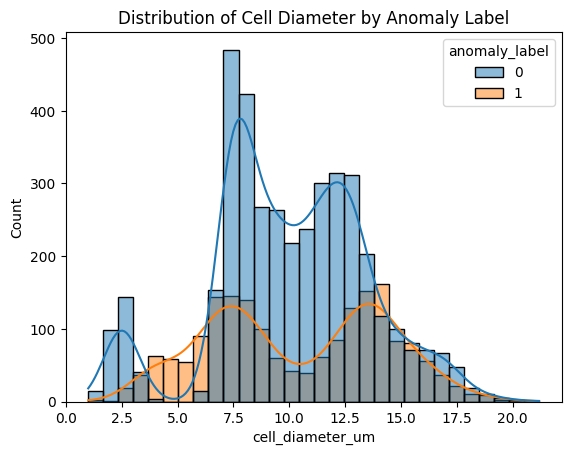

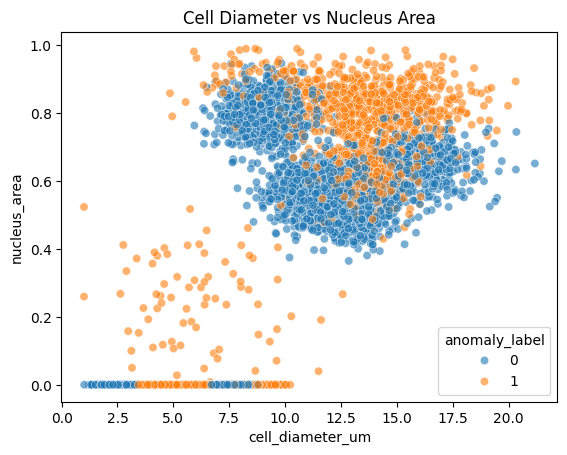

In [ ]:
# Histo Plot
sns.histplot(data=df, x='cell_diameter_um', hue='anomaly_label', bins=30, kde=True)
plt.title('Distribution of Cell Diameter by Anomaly Label')
plt.show()


# Scatter Plot
sns.scatterplot(data=df, x='cell_diameter_um', y='nucleus_area',  hue='anomaly_label', alpha=0.6)
plt.title('Cell Diameter vs Nucleus Area')
plt.show()

The histogram shows that normal and abnormal cells have overlapping distributions, but abnormal cells tend to appear more frequently at smaller diameters. This supports the boxplot that cell diameter has a relationship with the anomaly label, even if it is not perfectly separated. The spread of values also shows that size alone is not enough, but still plays an important role in classification.

The scatter plot shows that there is significant overlap between normal and abnormal cells, but some separation can be seen when both cell diameter and nucleus area are considered together. Abnormal cells tend to cluster in areas with smaller diameters and varying nucleus sizes, supporting the idea that combining these features helps reveal patterns. 

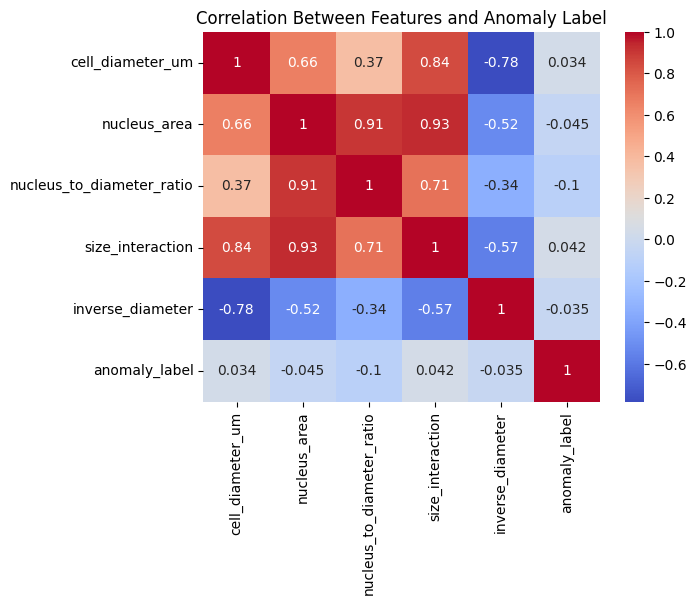

In [34]:
# Heat Corrolation

corr = df[['cell_diameter_um', 'nucleus_area', 'nucleus_to_diameter_ratio','size_interaction', 'inverse_diameter', 'anomaly_label']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Features and Anomaly Label')
plt.show()

The correlation heatmap shows that individual features such as cell diameter and nucleus area have very low correlation with the anomaly label, indicating that they are not strong predictors on their own. However, the engineered features show slightly stronger relationships, suggesting that combining measurements helps reveal patterns that are not obvious individually.

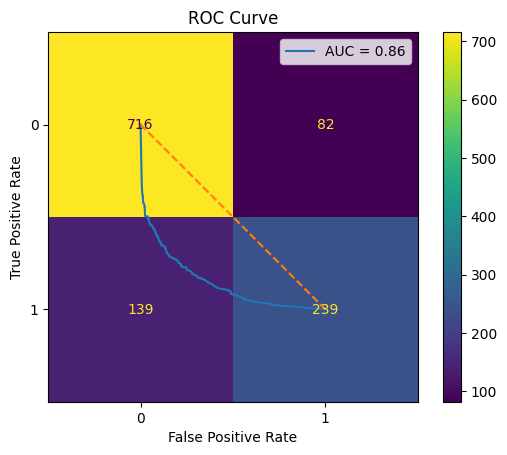

In [38]:
# Confusion Matrix Display
ConfusionMatrixDisplay.from_estimator(rf2, X_test, y_test)

# ROC Curve
y_probs = rf2.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


The ROC curve shows that the model performs well overall, with an AUC score of 0.86, showing a strong ability to distinguish between normal and abnormal cells. The curve staying above the diagonal line suggests that the model is making better predictions than random guessing. This supports the earlier results, showing that the model is learning meaningful patterns from the engineered features.

In [39]:
# Step 5 of Week 13

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Key Params": ["max_depth=5", "n_estimators=100"],
    "Accuracy": [0.83, 0.81],
    "Precision (1)": [0.80, 0.74],
    "Recall (1)": [0.62, 0.63],
    "F1 Score (1)": [0.70, 0.68]
})

print(comparison)

           Model        Key Params  Accuracy  Precision (1)  Recall (1)  \
0  Decision Tree       max_depth=5      0.83           0.80        0.62   
1  Random Forest  n_estimators=100      0.81           0.74        0.63   

   F1 Score (1)  
0          0.70  
1          0.68  


In [40]:
sample = X_test.iloc[:10]
preds = rf2.predict(sample)
probs = rf2.predict_proba(sample)

results = sample.copy()
results["Actual"] = y_test.iloc[:10].values
results["Predicted"] = preds
results["Confidence"] = probs.max(axis=1)

print(results)

      cell_diameter_um  nucleus_area  nucleus_to_diameter_ratio  \
5370             13.35         0.476                   0.035655   
5299              9.75         0.809                   0.082974   
199               8.74         0.807                   0.092334   
3268             10.87         0.619                   0.056946   
3504              3.58         0.000                   0.000000   
5585             10.78         0.738                   0.068460   
2344              7.75         0.000                   0.000000   
1611              9.80         0.819                   0.083571   
5755             11.04         0.602                   0.054529   
2201              7.85         0.000                   0.000000   

      size_interaction  inverse_diameter  Actual  Predicted  Confidence  
5370           6.35460          0.074906       0          0    0.980000  
5299           7.88775          0.102564       1          0    0.830000  
199            7.05318          0.114416

*(Example Prediction Analysis)*

The example predictions show that the model is able to correctly classify most normal cells with high confidence, often close to 1.00. However, there are some cases where abnormal cells are misclassified as normal, even when the confidence is still relatively high. This can tell us that while the model is generally accurate, it still struggles with certain abnormal patterns.

Looking at the feature values, many of the correctly classified normal cells have moderate to larger cell diameters and balanced nucleus areas. In contrast, some misclassified abnormal cells do not follow a clear pattern, which suggests that abnormal cells can vary more in these areas. This supports the earlier findings that abnormal cells are harder to predict because their characteristics are less consistent.

*(Performance Comparison)*

The comparison between the two models shows that the Decision Tree performs slightly better than the Random Forest, with an accuracy of 0.83 compared to 0.81. It also has higher precision and F1-score for abnormal cells, indicating that it is more effective at correctly identifying those cases. While both models perform similarly, the Decision Tree shows a small but consistent advantage.

*(Trade-off Analysis)*

The Decision Tree is simpler and easier to interpret, making it useful for understanding how features like cell diameter influence predictions. The Random Forest is more complex and generally more robust, but in this case, the added complexity does not result in better performance. This shows that increasing model complexity does not always lead to improved results, especially when the dataset already contains strong features.

*(Final Model Selection)*

Based on the results, the Decision Tree is the better choice for this problem. It provides slightly better performance while also being easier to interpret and faster to train. Since the goal of this project is to understand the relationship between cell features and the anomaly label, the simpler model is more useful because it makes those relationships clearer.

**Ethical Analysis & Responsible Deployment** #Step 6 of Week 13

One potential source of bias in this model comes from the dataset itself. If certain types of cells are more common than others like neutrophils, the model may become better at predicting those cases while performing worse on less common ones like basophils. This can be seen in the results, where abnormal cells are harder to classify compared to normal cells, which suggests an imbalance or lack of clear patterns in the data.

Another concern is the impact of incorrect predictions. A false negative, where an abnormal cell is classified as normal, could be more harmful because it may delay further analysis or treatment. While false positives are still an issue, they are less harmful since they would likely lead to additional tests and studys, rather than being ignored.

To reduce these risks, the model should not be used as a final decision-making tool. Instead, it should be used to support professionals by highlighting potential abnormal cells. The model should also be tested on more diverse datasets and updated over time to improve accuracy and reduce bias.

**Business Recommendations & Deployment Considerations** #Step 7 of Week 13

Based on the model’s predictions, this system could be used as a support tool to help identify abnormal cells more efficiently. By highlighting cells that are more likely to be abnormal, it can help professionals focus their attention on the most important cases and improve overall workflow.

For deployment, the model should not be fully automated. Instead, it should be used alongside human review to ensure accuracy and reduce the risk of incorrect classifications. A confidence threshold should also be applied so that only high-confidence predictions are trusted, while lower confidence cases are flagged for further review. It is also important to recognize the limitations of the model since the model is not perfect, especially when predicting abnormal cells. It should also have regular updates and monitoring that will help make sure it has the necessary maintance to perform and continues to work effectively over time.